# 7장 군집화

In [8]:
#1 K-평균 알고리즘 이해

In [9]:
#1.1 사이킷런 KMeans 클래스 소개
from sklearn.cluster import KMeans

# 최신 버전 표준 시그니처
kmeans = KMeans(n_clusters=8, init='k-means++', n_init='auto', max_iter=300, tol=0.0001, verbose=0, random_state=None, copy_x=True, algorithm='lloyd')

In [10]:
#1.2 K-평균을 이용한 붓꽃 데이터 세트 군집화

In [11]:
#1.2.1 Data load
from sklearn.preprocessing import scale
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

iris = load_iris()
##더 편리한 데이터 핸들링을 위해 DataFrame으로 변환
irisDF = pd.DataFrame(data=iris.data, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])
irisDF.head(3)

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [12]:
#1.2.2 군집화 및 fit
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300,random_state=0)
kmeans.fit(irisDF)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [13]:
#1.2.3 군집화한 결과 속성 확인
print(kmeans.labels_)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


In [14]:
#1.2.5 군집화를 시각화
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_transformed = pca.fit_transform(iris.data)

irisDF['target'] = pca_transformed[:,0]
irisDF['cluster']= pca_transformed[:,1]
irisDF.head(3)

,sepal_length,sepal_width,petal_length,petal_width,target,cluster
0,5.1,3.5,1.4,0.2,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,-2.888991,-0.144949


      pca_x     pca_y    target
0 -2.684126  0.319397 -2.684126
1 -2.714142 -0.177001 -2.714142
2 -2.888991 -0.144949 -2.888991


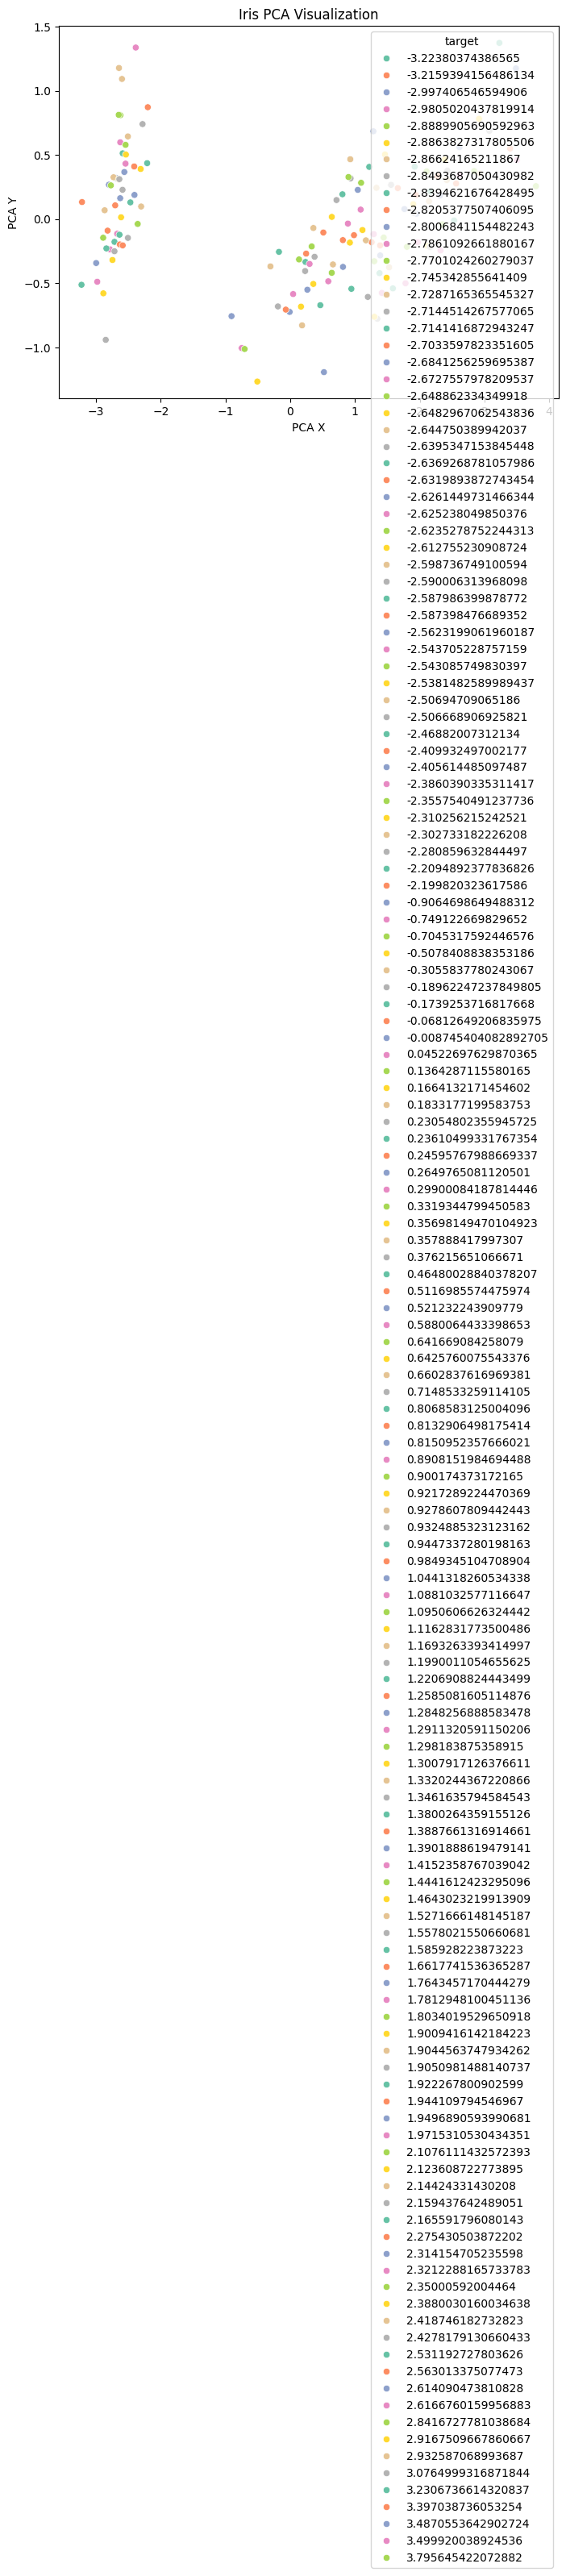

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# 1. PCA 변환 (2차원으로 축소)
pca = PCA(n_components=2)
pca_transformed = pca.fit_transform(iris.data)

# 2. 데이터프레임에 PCA x, y 좌표를 '새로운 컬럼'으로 추가
irisDF['pca_x'] = pca_transformed[:, 0]
irisDF['pca_y'] = pca_transformed[:, 1]

# 잘 들어갔는지 확인
print(irisDF[['pca_x', 'pca_y', 'target']].head(3))

# 3. 데이터 시각화 (산점도 그리기)
plt.figure(figsize=(8, 6))
# x축은 pca_x, y축은 pca_y, 색상(hue)은 실제 품종(target)으로 구분
sns.scatterplot(x='pca_x', y='pca_y', hue='target', palette='Set2', data=irisDF)

plt.title('Iris PCA Visualization')
plt.xlabel('PCA X')
plt.ylabel('PCA Y')
plt.show()

In [16]:
#1.2.4 groupby를 통해서 속성값에 따른 개수 파악
irisDF['target'] = iris.target
irisDF['cluster']= kmeans.labels_
iris_result = irisDF.groupby(['target', 'cluster'])['sepal_length'].count()
print(iris_result)

target  cluster
0       1          50
1       0          47
        2           3
2       0          14
        2          36
Name: sepal_length, dtype: int64


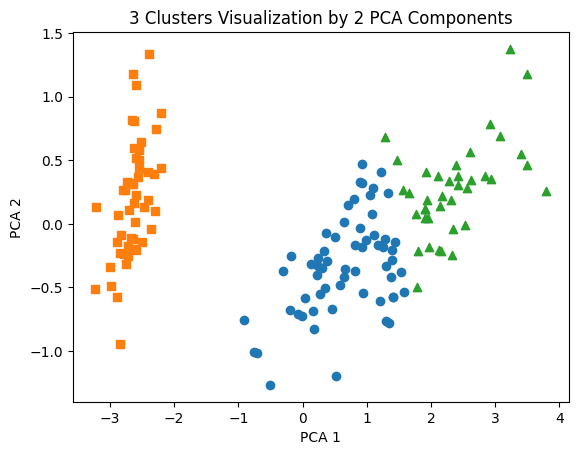

In [17]:
#1.2.6 산점도 
##군집 값이 0,1,2인 경우마다 별도의 인덱스로 추출
marker0_ind =irisDF[irisDF['cluster']==0].index
marker1_ind =irisDF[irisDF['cluster']==1].index
marker2_ind =irisDF[irisDF['cluster']==2].index

## 군집 값 0,1,2에 해당하는 인덱스로 각 군집 레벨의 pca_x, pca_y 값 추출. o,s,^로 마커 표시
plt.scatter(x=irisDF.loc[marker0_ind,'pca_x'], y=irisDF.loc[marker0_ind, 'pca_y'], marker='o')
plt.scatter(x=irisDF.loc[marker1_ind,'pca_x'], y=irisDF.loc[marker1_ind, 'pca_y'], marker='s')
plt.scatter(x=irisDF.loc[marker2_ind,'pca_x'], y=irisDF.loc[marker2_ind, 'pca_y'], marker='^')

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('3 Clusters Visualization by 2 PCA Components')
plt.show()

In [18]:
#1.3 군집화 알고리즘 테스트를 위한 데이터 생성

- make_blobs: 개별 군집의 중심점과 표준 편차 제어 기능이 추가
- make_classification: 노이즈를 포함한 데이터를 만드는 데 유용하게 사용

In [19]:
#1.3.1 make_blobs 사용 예시
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
%matplotlib inline
X,y = make_blobs(n_samples=200, n_features=2, centers=3, cluster_std=0.8, random_state=0)
print(X.shape, y.shape)

##y target 값의 분포를 확인
unique, counts = np.unique(y,return_counts=True)
print(unique, counts)

(200, 2) (200,)
[0 1 2] [67 67 66]


In [20]:
#1.3.2 dataframe으로 변경하여 쉽게 사용할 수 있게 만들기
import pandas as pd

clusterDF = pd.DataFrame(data=X, columns=['ftr1', 'ftr2'])
clusterDF['target'] = y
clusterDF.head(3)

,ftr1,ftr2,target
0,-1.692427,3.622025,2
1,0.697940,4.428867,0
2,1.100228,4.606317,0


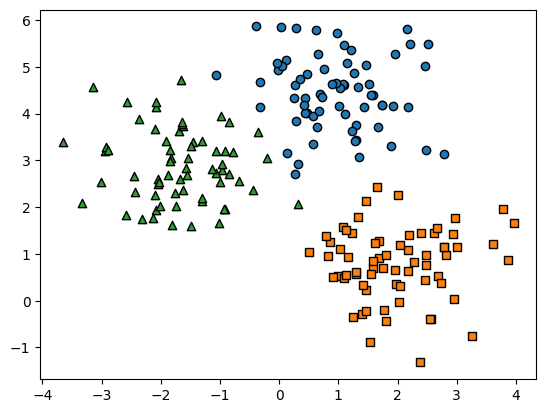

In [21]:
#1.3.3 시각화하여 군집화 확인
target_list = np.unique(y)
##각 타깃별 산점도의 마커 값. 
markers = ['o','s','^','P','D','H','x']
##3개의 군집 영역으로 구분한 데이터 세트를 생성했으므로 target_list는 [0,1,2]
##target==0, target==1, target==2로 scatter plot을 marker 별로 생성
for target in target_list:
    target_cluster = clusterDF[clusterDF['target']==target]
    plt.scatter(x=target_cluster['ftr1'],y=target_cluster['ftr2'],edgecolor='k',marker=markers[target] )
plt.show()

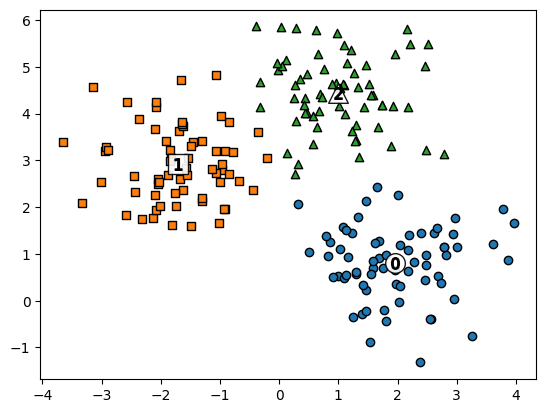

In [22]:
#1.3.4 중심 위치 좌표로 표시하기

##KMeans 객체를 이용해 X 데이터를 K-Means 클러스터링 수행
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=200, random_state=0)
cluster_labels = kmeans.fit_predict(X)
clusterDF['kmeans_label'] = cluster_labels

## Cluster_centers_ 는 개별 클러스터의 중심 위치 좌표 시각화를 위해 추출
centers = kmeans.cluster_centers_
unique_labels = np.unique(cluster_labels)
markers = ['o','s','^','P','D','H','x']

##군집된 label 유형별로 iteration하면서 marker 별로 scatter plot 수행.
for label in unique_labels:
    label_cluster = clusterDF[clusterDF['kmeans_label'] == label]
    center_x_y = centers[label]
    plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], edgecolor='k', marker=markers[label])

    ##군집별 중심 위치 좌표 시각화
    plt.scatter(x=center_x_y[0], y=center_x_y[1], s=200, color='white', alpha=0.9, edgecolor='k', marker=markers[label])
    plt.scatter(x=center_x_y[0], y=center_x_y[1], s=70, color='k', edgecolor='k', marker='$%d$' % label)

plt.show()

In [23]:
#타겟과 군집번호
print(clusterDF.groupby('target')['kmeans_label'].value_counts())

target  kmeans_label
0       2               66
        1                1
1       0               67
2       1               65
        0                1
Name: count, dtype: int64


In [24]:
#2. 군집 평가

#2.1 실루엣 분석의 개요: 좋은 군집화의 조건
1. 전체 실루엣 계수의 평균값이 1에 가까울수록 좋음
2. 평균값과 더불어 개별 군집의 평균값의 편차가 크지 않아야 함

In [25]:
#2.2 붓꽃 데이터 세트를 이용한 군집 평가

In [26]:
#2.2.1 
from sklearn.preprocessing import scale
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

##실루엣 분석 평가 지표 값을 구하기 위한 API 추가
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

iris = load_iris()
feature_names = ['sepal_length', 'sepal_width', 'petal_length' , 'petal_witdth']
irisDF = pd.DataFrame(data=iris.data, columns=feature_names)
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, random_state=0).fit(irisDF)
irisDF['cluster'] = kmeans.labels_

##iris의 모든 개별 데이터에 실루엣 계수 값을 구함
score_samples = silhouette_samples(iris.data, irisDF['cluster'])
print('silhouette_samples() return 값의 shape', score_samples.shape)

##irisDF에 실루엣 계수 칼럼 추가
irisDF['silhouette_coeff']=score_samples

##모든 데이터의 평균 실루엣 계수값을 구함
average_score = silhouette_score(iris.data, irisDF['cluster'])
print('붓꽃 데이터 세트 Silhouette Analysis Score: {0:.3f}'. format(average_score))
irisDF.head(3)

silhouette_samples() return 값의 shape (150,)
붓꽃 데이터 세트 Silhouette Analysis Score: 0.551


,sepal_length,sepal_width,petal_length,petal_witdth,cluster,silhouette_coeff
0,5.1,3.5,1.4,0.2,1,0.852582
1,4.9,3.0,1.4,0.2,1,0.814916
2,4.7,3.2,1.3,0.2,1,0.828797


In [27]:
#2.2.2 평균 실루엣 계수값
irisDF.groupby('cluster')['silhouette_coeff'].mean()

cluster
0    0.422323
1    0.797604
2    0.436842
Name: silhouette_coeff, dtype: float64

In [28]:
#2.3 군집별 평균 실루엣 계수의 시각화를 통한 군집 개수 최적화 방법

In [35]:
#visualize_silhouette 정의
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.cluster import KMeans

def visualize_silhouette(cluster_lists, X_features): 
    """
    여러 개의 군집 개수를 리스트로 받아 실루엣 분석 결과를 시각화하는 함수
    cluster_lists: 군집 개수 리스트 (예: [2, 3, 4, 5])
    X_features: 시각화할 데이터 세트
    """
    # 입력된 군집 개수 리스트의 길이만큼 그래프 열(column) 생성
    n_cols = len(cluster_lists)
    fig, axs = plt.subplots(figsize=(4*n_cols, 4), nrows=1, ncols=n_cols)
    
    # 리스트에 담긴 군집 개수들을 순차적으로 반복하며 시각화 수행
    for ind, n_cluster in enumerate(cluster_lists):
        
        # KMeans 군집화 수행
        clusterer = KMeans(n_clusters = n_cluster, max_iter=500, random_state=0)
        cluster_labels = clusterer.fit_predict(X_features)
        
        # 전체 데이터의 평균 실루엣 계수 계산
        sil_avg = silhouette_score(X_features, cluster_labels)
        # 개별 데이터의 실루엣 계수 계산
        sil_values = silhouette_samples(X_features, cluster_labels)
        
        y_lower = 10
        axs[ind].set_title('Number of Cluster : '+ str(n_cluster)+'\n' \
                          'Silhouette Score :' + str(round(sil_avg,3)) )
        axs[ind].set_xlabel("The silhouette coefficient values")
        axs[ind].set_ylabel("Cluster label")
        axs[ind].set_xlim([-0.1, 1])
        axs[ind].set_ylim([0, len(X_features) + (n_cluster + 1) * 10])
        axs[ind].set_yticks([])  # y축 라벨 제거
        axs[ind].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        
        # 클러스터별로 실루엣 계수를 시각화
        for i in range(n_cluster):
            ith_cluster_sil_values = sil_values[cluster_labels==i]
            ith_cluster_sil_values.sort()
            
            size_cluster_i = ith_cluster_sil_values.shape[0]
            y_upper = y_lower + size_cluster_i
            
            # 클러스터별 색상 지정
            color = cm.nipy_spectral(float(i) / n_cluster)
            axs[ind].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values, \
                                facecolor=color, edgecolor=color, alpha=0.7)
            axs[ind].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10
            
        # 전체 평균 실루엣 계수를 빨간 점선으로 표시
        axs[ind].axvline(x=sil_avg, color="red", linestyle="--")

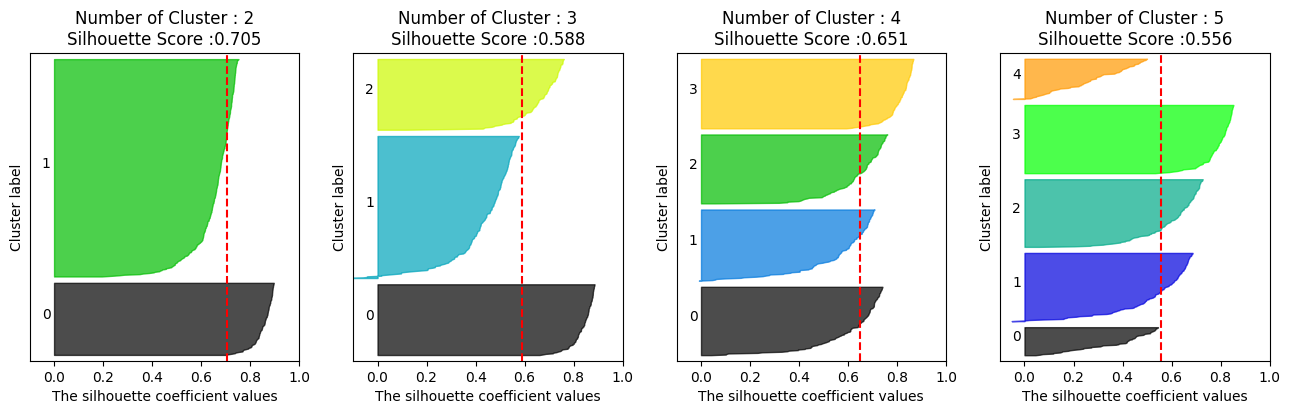

In [39]:
#2.3.1  visualize_silhouette : 군집 개수를 변화시키면서 K-평균 군집을 수행했을 때 
#개별 군집별 평균 실루엣 게수 값을 시각화해서 군집의 개수를 정하는 데 도움
X_features, y_labels = make_blobs(n_samples=500, n_features=2, centers=4, cluster_std=1, 
                                  center_box=(-10.0, 10.0), shuffle=True, random_state=1)
visualize_silhouette([2,3,4,5],X_features) ##2~5개와 같이 군집의 개수의 case를 여러 개로 바꾸면서 비교

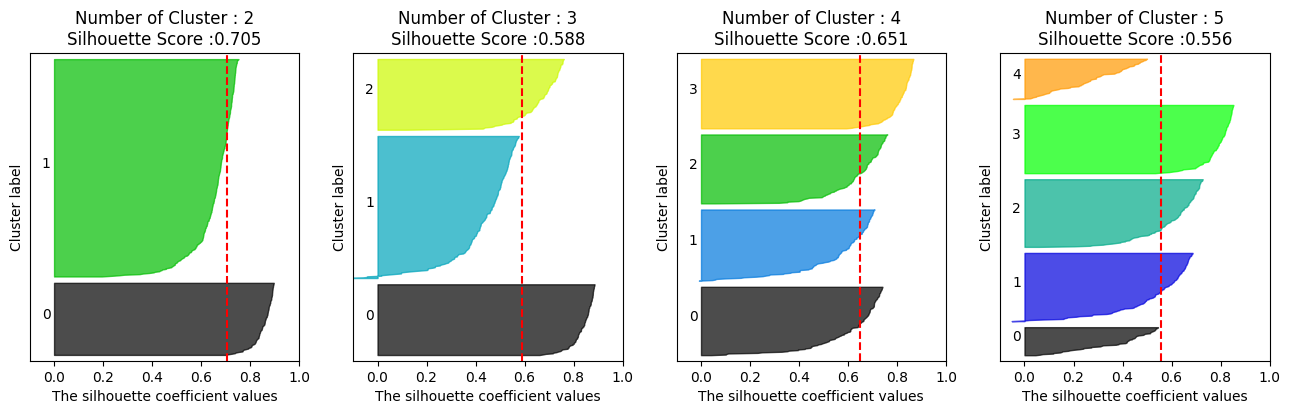

In [41]:
#2.3.2 2~5개의 군집개수별 평균값 비교

## make_blobs를 통해 군집화를 위한 4개의 군집 중심의 500개 2차원 데이터 세트 생성
from sklearn.datasets import make_blobs
X,y = make_blobs(n_samples=500, n_features=2, centers=4, cluster_std=1, center_box=(-10.0,10.0), shuffle=True, random_state=1)

##군집 개수가 2,3,4,5개일 때의 군집별 실루엣 계수 평균값을 시각화
visualize_silhouette([2,3,4,5],X)

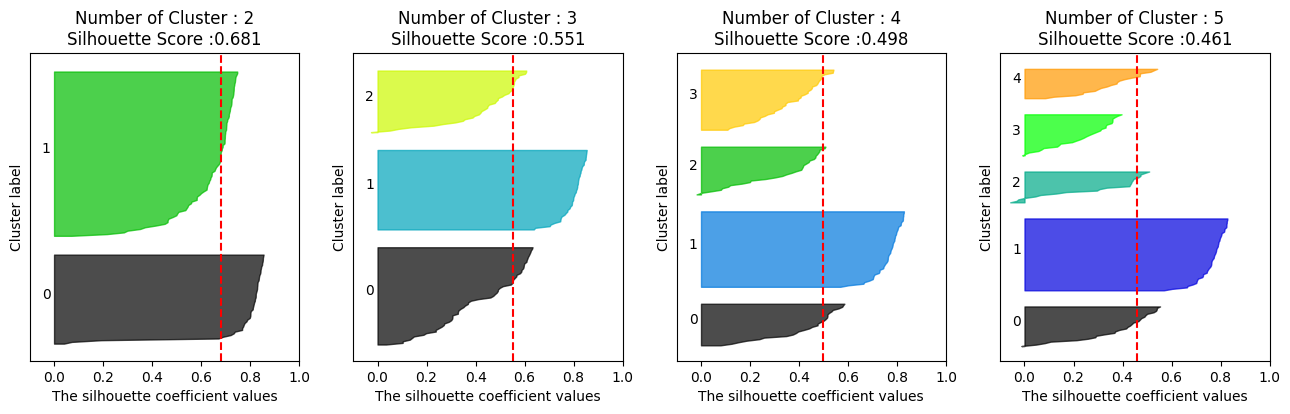

In [38]:
#2.3.3 최적의 군집 개수 파악

from sklearn.datasets import load_iris
iris=load_iris()
visualize_silhouette([2,3,4,5], iris.data)